In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import linregress

In [36]:
import pandas as pd

fund_master = pd.read_csv(
    "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/raw/01_fund_master.csv"
)

nav_history = pd.read_csv(
    "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/raw/02_nav_history.csv"
)

aum_by_fund_house = pd.read_csv(
    "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/raw/03_aum_by_fund_house.csv"
)

monthly_sip_inflows = pd.read_csv(
    "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/raw/04_monthly_sip_inflows.csv"
)

category_inflows = pd.read_csv(
    "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/raw/05_category_inflows.csv"
)

industry_folio_count = pd.read_csv(
    "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/raw/06_industry_folio_count.csv"
)

scheme_performance = pd.read_csv(
    "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/raw/07_scheme_performance.csv"
)

investor_transactions = pd.read_csv(
    "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/raw/08_investor_transactions.csv"
)

portfolio_holdings = pd.read_csv(
    "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/raw/09_portfolio_holdings.csv"
)

benchmark_indices = pd.read_csv(
    "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/raw/10_benchmark_indices.csv"
)

# Create dictionary
datasets = {
    "fund_master": fund_master,
    "nav_history": nav_history,
    "aum_by_fund_house": aum_by_fund_house,
    "monthly_sip_inflows": monthly_sip_inflows,
    "category_inflows": category_inflows,
    "industry_folio_count": industry_folio_count,
    "scheme_performance": scheme_performance,
    "investor_transactions": investor_transactions,
    "portfolio_holdings": portfolio_holdings,
    "benchmark_indices": benchmark_indices
}

# Remove Unnamed columns
for name, df in datasets.items():
    datasets[name] = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# Assign back to variables
fund_master = datasets["fund_master"]
nav_history = datasets["nav_history"]
aum_by_fund_house = datasets["aum_by_fund_house"]
monthly_sip_inflows = datasets["monthly_sip_inflows"]
category_inflows = datasets["category_inflows"]
industry_folio_count = datasets["industry_folio_count"]
scheme_performance = datasets["scheme_performance"]
investor_transactions = datasets["investor_transactions"]
portfolio_holdings = datasets["portfolio_holdings"]
benchmark_indices = datasets["benchmark_indices"]

print("Unnamed columns removed successfully!")

Unnamed columns removed successfully!


In [37]:
print(nav_history.head())
print(nav_history.columns)

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692
Index(['amfi_code', 'date', 'nav'], dtype='object')


Daily Return 

In [38]:
nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
               .pct_change()
)

In [39]:
print(nav_history.columns)
print()

print(scheme_performance.columns)
print()

print(benchmark_indices.columns)
print()

print(fund_master.columns)

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='object')

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

Index(['date', 'index_name', 'close_value'], dtype='object')

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')


In [40]:
nav_history = nav_history.loc[
    :,
    ~nav_history.columns.str.contains('Unnamed')
]

In [41]:
nav_history['date'] = pd.to_datetime(nav_history['date'])

nav_history['nav'] = pd.to_numeric(
    nav_history['nav'],
    errors='coerce'
)

In [42]:
print(nav_history.shape)

print(nav_history.head())

(46000, 4)
   amfi_code       date      nav  daily_return
0     119551 2022-01-03  54.3856           NaN
1     119551 2022-01-04  54.3474     -0.000702
2     119551 2022-01-05  54.6869      0.006247
3     119551 2022-01-06  55.4550      0.014045
4     119551 2022-01-07  55.3692     -0.001547


Data Preparation

In [43]:
nav_history['date'] = pd.to_datetime(nav_history['date'])

nav_history['nav'] = pd.to_numeric(
    nav_history['nav'],
    errors='coerce'
)

nav_history.dropna(inplace=True)

print(nav_history.head())

   amfi_code       date      nav  daily_return
1     119551 2022-01-04  54.3474     -0.000702
2     119551 2022-01-05  54.6869      0.006247
3     119551 2022-01-06  55.4550      0.014045
4     119551 2022-01-07  55.3692     -0.001547
5     119551 2022-01-10  55.2835     -0.001548


Daily Returns

In [44]:
daily_returns = nav_history.copy()

daily_returns['daily_return'] = (
    daily_returns
    .groupby('amfi_code')['nav']
    .pct_change()
)

daily_returns.head()

,amfi_code,date,nav,daily_return
1,119551,2022-01-04,54.3474,NaN
2,119551,2022-01-05,54.6869,0.006247
3,119551,2022-01-06,55.4550,0.014045
4,119551,2022-01-07,55.3692,-0.001547
5,119551,2022-01-10,55.2835,-0.001548


Distribution Check

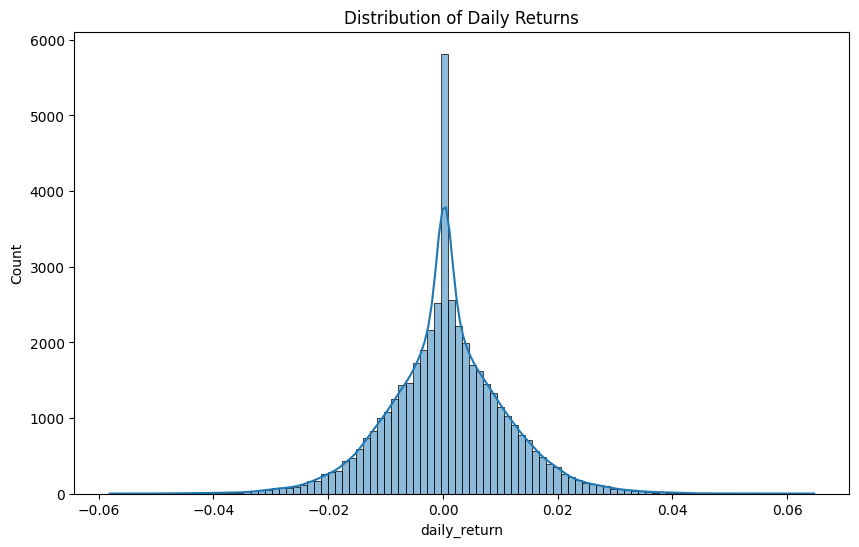

In [45]:
plt.figure(figsize=(10,6))

sns.histplot(
    daily_returns['daily_return'],
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.show()

CAGR

In [46]:
cagr_results = []

for fund in nav_history['amfi_code'].unique():

    temp = nav_history[
        nav_history['amfi_code'] == fund
    ].sort_values('date')

    nav_start = temp['nav'].iloc[0]
    nav_end = temp['nav'].iloc[-1]

    years = (
        (temp['date'].max() -
         temp['date'].min()).days
    ) / 365

    cagr = (
        (nav_end / nav_start)
        ** (1 / years)
    ) - 1

    cagr_results.append(
        [fund, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=['amfi_code', 'cagr']
)

cagr_df.head()

,amfi_code,cagr
0,119551,0.258230
1,119552,0.220341
2,119598,0.328687
3,119599,0.024935
4,119120,0.058254


Sharpe Ratio

In [47]:
rf = 0.065

sharpe_results = []

for fund in daily_returns['amfi_code'].unique():

    temp = daily_returns[
        daily_returns['amfi_code'] == fund
    ]

    mean_return = temp['daily_return'].mean()

    std_return = temp['daily_return'].std()

    sharpe = (
        (mean_return - rf/252)
        / std_return
    ) * np.sqrt(252)

    sharpe_results.append(
        [fund, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=['amfi_code', 'sharpe_ratio']
)

sharpe_df.sort_values(
    'sharpe_ratio',
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,1.422040
22,120843,1.284220
36,148569,1.225614
0,119551,1.210344
12,120505,1.205121


Sortino Ratio

In [48]:
sortino_results = []

for fund in daily_returns['amfi_code'].unique():

    temp = daily_returns[
        daily_returns['amfi_code'] == fund
    ]

    downside = temp[
        temp['daily_return'] < 0
    ]['daily_return']

    downside_std = downside.std()

    mean_return = temp['daily_return'].mean()

    sortino = (
        (mean_return - rf/252)
        / downside_std
    ) * np.sqrt(252)

    sortino_results.append(
        [fund, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=['amfi_code', 'sortino_ratio']
)

Alpha & Beta

clean Benchmark Dataset 

In [49]:
print(benchmark_indices.columns)

print(benchmark_indices.head())

Index(['date', 'index_name', 'close_value'], dtype='object')
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15


In [50]:
benchmark_indices = benchmark_indices.loc[
    :,
    ~benchmark_indices.columns.str.contains('Unnamed')
]

benchmark_indices['date'] = pd.to_datetime(
    benchmark_indices['date']
)

benchmark_indices['close_value'] = pd.to_numeric(
    benchmark_indices['close_value'],
    errors='coerce'
)

Use NIFTY100 as Benchmark

In [51]:
nifty100 = benchmark_indices[
    benchmark_indices['index_name'] == 'NIFTY100'
].copy()

Calculate Benchmark Returns

In [52]:
nifty100['benchmark_return'] = (
    nifty100['close_value']
    .pct_change()
)

benchmark_returns = nifty100[
    ['date', 'benchmark_return']
]

print(benchmark_returns.head())

           date  benchmark_return
1150 2022-01-03               NaN
1151 2022-01-04         -0.013540
1152 2022-01-05          0.004003
1153 2022-01-06         -0.002935
1154 2022-01-07          0.006150


In [53]:
from scipy.stats import linregress
alpha_beta = []

for fund in daily_returns['amfi_code'].unique():

    temp = daily_returns[
        daily_returns['amfi_code'] == fund
    ]

    merged = pd.merge(
        temp,
        benchmark_returns,
        on='date'
    )

    beta, alpha, r, p, se = linregress(
        merged['benchmark_return'],
        merged['daily_return']
    )

    alpha_beta.append([
        fund,
        alpha * 252,
        beta
    ])

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        'amfi_code',
        'alpha',
        'beta'
    ]
)

Maximum Drawdown

In [54]:
mdd_results = []

for fund in nav_history['amfi_code'].unique():

    temp = nav_history[
        nav_history['amfi_code'] == fund
    ].sort_values('date')

    running_max = temp['nav'].cummax()

    drawdown = (
        temp['nav']
        / running_max
    ) - 1

    mdd = drawdown.min()

    mdd_results.append(
        [fund, mdd]
    )

mdd_df = pd.DataFrame(
    mdd_results,
    columns=[
        'amfi_code',
        'max_drawdown'
    ]
)

Fund Scorecard

In [55]:
cagr_df
sharpe_df
alpha_beta_df
mdd_df
scheme_performance

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,0.97,1.06,1.70,14.0,-17.41,6434,1.55,5,Moderate
6,125497,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Mutual Fund,Large Cap,Direct,11.48,13.38,13.48,12.25,1.13,0.97,0.96,1.45,14.0,-33.50,10611,0.92,4,Moderate
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,15.63,0.95,0.91,0.87,1.44,19.0,-13.67,23185,1.38,5,High
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Mid Cap,Direct,19.98,15.29,15.85,14.39,0.90,1.04,0.80,1.38,19.0,-32.22,18792,0.78,4,High
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,0.44,1.84,2.79,4.0,-6.01,27953,0.56,3,Low


In [56]:
print(cagr_df.head())

print(sharpe_df.head())

print(alpha_beta_df.head())

print(mdd_df.head())

print(scheme_performance.columns)

   amfi_code      cagr
0     119551  0.258230
1     119552  0.220341
2     119598  0.328687
3     119599  0.024935
4     119120  0.058254
   amfi_code  sharpe_ratio
0     119551      1.210344
1     119552      0.984947
2     119598      0.959228
3     119599     -0.040551
4     119120     -0.240007
   amfi_code  alpha  beta
0     119551    NaN   NaN
1     119552    NaN   NaN
2     119598    NaN   NaN
3     119599    NaN   NaN
4     119120    NaN   NaN
   amfi_code  max_drawdown
0     119551     -0.150124
1     119552     -0.118035
2     119598     -0.287060
3     119599     -0.525742
4     119120     -0.043287
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')


Create Scorecard DataFrame

In [57]:
scorecard = cagr_df.merge(
    sharpe_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    mdd_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    scheme_performance[
        [
            'amfi_code',
            'return_3yr_pct',
            'expense_ratio_pct'
        ]
    ],
    on='amfi_code'
)

print(scorecard.head())

   amfi_code      cagr  sharpe_ratio  max_drawdown  return_3yr_pct  \
0     119551  0.258230      1.210344     -0.150124           12.36   
1     119552  0.220341      0.984947     -0.118035           11.30   
2     119598  0.328687      0.959228     -0.287060           23.39   
3     119599  0.024935     -0.040551     -0.525742           23.14   
4     119120  0.058254     -0.240007     -0.043287            6.07   

   expense_ratio_pct  
0               1.54  
1               0.66  
2               1.43  
3               0.72  
4               0.77  


Create Rankings

In [58]:
scorecard['cagr_rank'] = (
    scorecard['cagr']
    .rank(ascending=False)
)

scorecard['sharpe_rank'] = (
    scorecard['sharpe_ratio']
    .rank(ascending=False)
)

scorecard['drawdown_rank'] = (
    scorecard['max_drawdown']
    .rank(ascending=False)
)

scorecard['expense_rank'] = (
    scorecard['expense_ratio_pct']
    .rank(ascending=True)
)

Temporary Score (Without Alpha)

In [59]:
scorecard['score'] = (
      scorecard['cagr_rank'] * 0.40
    + scorecard['sharpe_rank'] * 0.30
    + scorecard['expense_rank'] * 0.15
    + scorecard['drawdown_rank'] * 0.15
)

In [60]:
scorecard = scorecard.sort_values(
    'score'
)

scorecard.head(10)

,amfi_code,cagr,sharpe_ratio,max_drawdown,return_3yr_pct,expense_ratio_pct,cagr_rank,sharpe_rank,drawdown_rank,expense_rank,score
34,148567,0.304036,1.422040,-0.112657,14.81,1.46,6.0,1.0,8.0,23.0,7.350
12,120505,0.334332,1.205121,-0.181885,18.08,1.36,1.0,5.0,25.0,15.0,7.900
22,120843,0.303709,1.284220,-0.129740,15.65,1.45,7.0,2.0,13.0,22.0,8.650
7,100033,0.305184,1.110623,-0.162172,16.58,1.38,5.0,7.0,20.0,17.0,9.650
11,120504,0.236171,1.045725,-0.125883,14.41,0.80,12.0,9.0,12.0,12.0,11.100
36,148569,0.316973,1.225614,-0.163967,13.58,1.60,4.0,3.0,21.0,36.5,11.125
1,119552,0.220341,0.984947,-0.118035,11.30,0.66,15.0,12.0,11.0,4.0,11.850
0,119551,0.258230,1.210344,-0.150124,12.36,1.54,10.0,4.0,17.0,30.5,12.325
2,119598,0.328687,0.959228,-0.287060,23.39,1.43,2.0,14.0,36.0,21.0,13.550
26,119094,0.283175,1.003086,-0.209609,15.18,1.38,9.0,11.0,28.0,17.0,13.650


In [61]:
scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

print("Scorecard Saved")

Scorecard Saved


In [62]:
print(daily_returns['date'].dtype)

print(benchmark_returns['date'].dtype)

datetime64[ns]
datetime64[ns]


In [63]:
print(daily_returns['date'].min())
print(daily_returns['date'].max())

print(benchmark_returns['date'].min())
print(benchmark_returns['date'].max())

2022-01-04 00:00:00
2026-05-29 00:00:00
2022-01-03 00:00:00
2026-05-29 00:00:00


In [64]:
print(nav_history.head(10))

print(nav_history.dtypes)

print(nav_history['nav'].head(10))

    amfi_code       date      nav  daily_return
1      119551 2022-01-04  54.3474     -0.000702
2      119551 2022-01-05  54.6869      0.006247
3      119551 2022-01-06  55.4550      0.014045
4      119551 2022-01-07  55.3692     -0.001547
5      119551 2022-01-10  55.2835     -0.001548
6      119551 2022-01-11  56.0878      0.014549
7      119551 2022-01-12  56.4978      0.007310
8      119551 2022-01-13  56.2934     -0.003618
9      119551 2022-01-14  56.5926      0.005315
10     119551 2022-01-17  56.3908     -0.003566
amfi_code                int64
date            datetime64[ns]
nav                    float64
daily_return           float64
dtype: object
1     54.3474
2     54.6869
3     55.4550
4     55.3692
5     55.2835
6     56.0878
7     56.4978
8     56.2934
9     56.5926
10    56.3908
Name: nav, dtype: float64


In [65]:
print(nav_history['nav'].unique()[:20])

[54.3474 54.6869 55.455  55.3692 55.2835 56.0878 56.4978 56.2934 56.5926
 56.3908 56.1887 56.3378 55.4237 54.6151 54.373  53.9173 54.0948 53.6911
 53.0538 53.7718]


In [66]:
print(nav_history.shape)

(45960, 4)


In [67]:
nav_history = pd.read_csv(
    "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/raw/02_nav_history.csv"
)

print("Before:", nav_history.shape)

nav_history['nav'] = pd.to_numeric(
    nav_history['nav'],
    errors='coerce'
)

print(nav_history['nav'].isna().sum())

print("After conversion:", nav_history.shape)

Before: (46000, 7)
0
After conversion: (46000, 7)


In [68]:
nav_history = pd.read_csv(
    "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/raw/02_nav_history.csv"
)

print(nav_history.head())

print(nav_history.iloc[0])

   amfi_code        date      nav  Unnamed: 3  Unnamed: 4  Unnamed: 5  \
0     119551  2022-01-03  54.3856         NaN         NaN         NaN   
1     119551  2022-01-04  54.3474         NaN         NaN         NaN   
2     119551  2022-01-05  54.6869         NaN         NaN         NaN   
3     119551  2022-01-06  55.4550         NaN         NaN         NaN   
4     119551  2022-01-07  55.3692         NaN         NaN         NaN   

   Unnamed: 6  
0         NaN  
1         NaN  
2         NaN  
3         NaN  
4         NaN  
amfi_code         119551
date          2022-01-03
nav              54.3856
Unnamed: 3           NaN
Unnamed: 4           NaN
Unnamed: 5           NaN
Unnamed: 6           NaN
Name: 0, dtype: object


In [69]:
print(nav_history.head())
print(nav_history.dtypes)

   amfi_code        date      nav  Unnamed: 3  Unnamed: 4  Unnamed: 5  \
0     119551  2022-01-03  54.3856         NaN         NaN         NaN   
1     119551  2022-01-04  54.3474         NaN         NaN         NaN   
2     119551  2022-01-05  54.6869         NaN         NaN         NaN   
3     119551  2022-01-06  55.4550         NaN         NaN         NaN   
4     119551  2022-01-07  55.3692         NaN         NaN         NaN   

   Unnamed: 6  
0         NaN  
1         NaN  
2         NaN  
3         NaN  
4         NaN  
amfi_code       int64
date           object
nav           float64
Unnamed: 3    float64
Unnamed: 4    float64
Unnamed: 5    float64
Unnamed: 6    float64
dtype: object
